In [2]:
import numpy as np
import os
import glob
import json
from datetime import datetime, timedelta
from typing import List, Callable, Union, Any, TypeVar, Tuple, Dict
Tensor = TypeVar('torch.tensor')
from abc import abstractmethod

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import PreTrainedModel, PretrainedConfig
from transformers import TrainingArguments, Trainer
from safetensors.torch import load_file

In [3]:
class LazyDataset1Chan(Dataset):
    def __init__(self, data_files, transform=None, time_interval=timedelta(minutes=10)):
        self.data_files=data_files
        self.transform = transform
        self.time_interval = time_interval

        # Build a mapping from datetime -> filepath
        self.time_format = "%Y%m%d%H%M"
        self.time_to_file = {}
        for f in self.data_files:
            ts = os.path.splitext(os.path.basename(f))[0]
            try:
                dt = datetime.strptime(ts, self.time_format)
                self.time_to_file[dt] = f
            except ValueError:
                continue  # Skip malformed filenames

        # Sort the datetimes
        sorted_times = sorted(self.time_to_file.keys())

        # Build valid pairs [t-interval, t]
        self.time_list = []
        for t in sorted_times:
            next_t = t - self.time_interval #t-1
            next_t_2 = next_t - self.time_interval #t-2
            next_t_3 = next_t_2 - self.time_interval #t-3
            if next_t in self.time_to_file and next_t_2 in self.time_to_file and next_t_3 in self.time_to_file:
                self.time_list.append((self.time_to_file[t], 
                                       self.time_to_file[next_t], 
                                       self.time_to_file[next_t_2], 
                                       self.time_to_file[next_t_3]))

    def __len__(self):
        return len(self.time_list)

    def __getitem__(self, idx):
        f_t, f_t_1, f_t_2, f_t_3 = self.time_list[idx]
        full_str = f'{os.path.basename(f_t_3)},{os.path.basename(f_t_2)},{os.path.basename(f_t_1)}'
        # Load data
        data_list = []
        for t_step in [f_t]: #1_channel
            data=torch.load(t_step).unsqueeze(0)
            if self.transform:
                data = self.transform(data)
            data_list.append(data)
        data=torch.cat(data_list, dim=0)

        return {'input': data, 'source': full_str}

class MinMaxToMinusOneOne:
    def __init__(self, min_vals, max_vals, ):
        self.min_vals = torch.tensor(min_vals).view(-1, 1, 1)
        self.max_vals = torch.tensor(max_vals).view(-1, 1, 1)
        
    def __call__(self, x):
        # x: [C, H, W]
        x = (x - self.min_vals) / (self.max_vals - self.min_vals + 1e-6)  # → [0, 1]
        return x * 2.0 - 1.0  # → [-1, 1]

In [4]:
class BaseVAE(nn.Module):
    def __init__(self) -> None:
        super(BaseVAE, self).__init__()

    def encode(self, input: Tensor) -> List[Tensor]:
        raise NotImplementedError

    def decode(self, input: Tensor) -> Any:
        raise NotImplementedError

    def sample(self, batch_size:int, current_device: int, **kwargs) -> Tensor:
        raise NotImplementedError

    def generate(self, x: Tensor, **kwargs) -> Tensor:
        raise NotImplementedError

    @abstractmethod
    def forward(self, *inputs: Tensor) -> Tensor:
        pass

    @abstractmethod
    def loss_function(self, *inputs: Any, **kwargs) -> Tensor:
        pass


class VanillaVAE(BaseVAE):
    def __init__(self,
                 input_size: int,
                 in_channels: int,
                 latent_dim: int,
                 hidden_dims: List = None,
                 **kwargs) -> None:
        super(VanillaVAE, self).__init__()

        self.input_size = input_size
        self.latent_dim = latent_dim
        self.in_channels = in_channels
        modules = []
        if hidden_dims is None:
            hidden_dims = [256, 512]

        # Build Encoder
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, out_channels=h_dim,
                              kernel_size= 3, stride= 2, padding  = 1),
                    nn.GroupNorm(num_groups=max(2, int(h_dim/16)), num_channels=h_dim),
                    nn.LeakyReLU())
            )
            in_channels = h_dim

        
        self.encoder = nn.Sequential(*modules) # [B, hidden_dim[-1], 8, 8]
        self.fc_mu = nn.Conv2d(hidden_dims[-1], latent_dim, 3, 1, 1)
        self.fc_var = nn.Conv2d(hidden_dims[-1], latent_dim, 3, 1, 1)

        # Build Decoder
        modules = []
        self.decoder_input = nn.Conv2d(latent_dim, hidden_dims[-1], 3, 1, 1)

        hidden_dims.reverse()

        for i in range(len(hidden_dims) - 1):
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(hidden_dims[i],
                                       hidden_dims[i + 1],
                                       kernel_size=3,
                                       stride = 2,
                                       padding=1,
                                       output_padding=1),
                    #nn.BatchNorm2d(hidden_dims[i + 1]),
                    nn.GroupNorm(num_groups=max(2, int(hidden_dims[i + 1]/16)), num_channels=hidden_dims[i + 1]),
                    nn.LeakyReLU())
            )

        self.decoder = nn.Sequential(*modules)

        self.final_layer = nn.Sequential(
                            nn.ConvTranspose2d(hidden_dims[-1],
                                               hidden_dims[-1],
                                               kernel_size=3,
                                               stride=2,
                                               padding=1,
                                               output_padding=1),
                            nn.GroupNorm(num_groups=max(2, int(hidden_dims[-1]/16)), num_channels=hidden_dims[-1]),
                            nn.LeakyReLU(),
                            nn.Conv2d(hidden_dims[-1], out_channels= self.in_channels,
                                      kernel_size= 3, padding= 1),
                            nn.Tanh())

    def encode(self, input: Tensor) -> List[Tensor]:
        result = self.encoder(input)

        # Split the result into mu and var components
        # of the latent Gaussian distribution
        mu = self.fc_mu(result)
        log_var = self.fc_var(result)
        return mu, log_var

    def decode(self, z: Tensor) -> Tensor:
        result = self.decoder_input(z)
        result = self.decoder(result)
        result = self.final_layer(result)
        return result

    def reparameterize(self, mu: Tensor, logvar: Tensor) -> Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return eps * std + mu

    def forward(self, input: Tensor, **kwargs) -> List[Tensor]:
        mu, log_var = self.encode(input)
        z = self.reparameterize(mu, log_var)
        return  self.decode(z), mu, log_var

    def sample(self,
               num_samples:int,
               current_device: int, **kwargs) -> Tensor:
        z = torch.randn(num_samples,
                        self.latent_dim)

        z = z.to(current_device)

        samples = self.decode(z)
        return samples

    def generate(self, x: Tensor, **kwargs) -> Tensor:
        return self.forward(x)[0]


def vae_loss(recons, input, mu, log_var, **kwargs) -> tuple:
        recons_loss =F.mse_loss(recons, input, reduction='mean')

        kld_loss =-0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

        loss = recons_loss + 0.00025* kld_loss
        return loss, recons_loss.detach(), -kld_loss.detach()

In [5]:
torch.manual_seed(42)
input_dir='/scratch/nf33/cd3022/pyearth'
device = torch.device("cuda")
checkpoint_path = ''
output_dir='/scratch/nf33/cd3022/pyearth/model/vae/target'
        
with open('/scratch/nf33/cd3022/pyearth/min_max.json', 'r') as f:
    stats = json.load(f)
    min_vals, max_vals = torch.tensor(stats['min'], dtype=torch.float32), torch.tensor(stats['max'], dtype=torch.float32)

data_files=sorted(glob.glob(os.path.join(input_dir, '*.pt')))
dataset = LazyDataset1Chan(data_files, transform=MinMaxToMinusOneOne(min_vals, max_vals))
dataloader = torch.utils.data.DataLoader(dataset, 
                                         batch_size=2, 
                                         shuffle=True)

vae = VanillaVAE(input_size=64, in_channels=1, latent_dim=1).to(device)
    
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-4)
epochs = 600
for epoch in range(epochs):
    vae.train()
    total_loss = 0
    for batch in dataloader:
        batch = batch['input'].to(torch.float32).to(device)
        optimizer.zero_grad()

        recon, mu, logvar = vae(batch)
        loss, rec_l, kl_l = vae_loss(recon, batch, mu, logvar)

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch)

    avg_loss = total_loss / len(dataloader)
    #print(f"Epoch {epoch+1:02d}: total={total_loss/len(loader.dataset):.4f}")
    if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1:02d}: total={total_loss/len(dataloader):.4f}")
            ckpt_path = os.path.join(output_dir, f"checkpoints/vae_epoch_{epoch+1}.pt")
            os.makedirs(os.path.join(output_dir, "checkpoints"), exist_ok=True)
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': vae.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, ckpt_path)
            print(f"💾 Saved checkpoint at: {ckpt_path}")
    #torch.save(vae.state_dict(), os.path.join(output_dir, str(epoch), "vae_model.pt")
print("✅ Training finished and model saved.")

/jobfs/163255815.gadi-pbs/ipykernel_4021673/2919720081.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.min_vals = torch.tensor(min_vals).view(-1, 1, 1)
/jobfs/163255815.gadi-pbs/ipykernel_4021673/2919720081.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.max_vals = torch.tensor(max_vals).view(-1, 1, 1)


Epoch 100: total=0.0138
💾 Saved checkpoint at: /scratch/nf33/cd3022/pyearth/model/vae/target/checkpoints/vae_epoch_100.pt
Epoch 200: total=0.0096
💾 Saved checkpoint at: /scratch/nf33/cd3022/pyearth/model/vae/target/checkpoints/vae_epoch_200.pt
Epoch 300: total=0.0058
💾 Saved checkpoint at: /scratch/nf33/cd3022/pyearth/model/vae/target/checkpoints/vae_epoch_300.pt
Epoch 400: total=0.0077
💾 Saved checkpoint at: /scratch/nf33/cd3022/pyearth/model/vae/target/checkpoints/vae_epoch_400.pt
Epoch 500: total=0.0041
💾 Saved checkpoint at: /scratch/nf33/cd3022/pyearth/model/vae/target/checkpoints/vae_epoch_500.pt
Epoch 600: total=0.0030
💾 Saved checkpoint at: /scratch/nf33/cd3022/pyearth/model/vae/target/checkpoints/vae_epoch_600.pt
✅ Training finished and model saved.


In [6]:
loader = DataLoader(dataset, batch_size=2, shuffle=False, num_workers=2)
data_sample = next(iter(loader))
data_sample['input'].shape #B, C, H, W

torch.Size([2, 1, 64, 64])

In [7]:
ckpt_path = os.path.join(output_dir, "checkpoints/vae_epoch_400.pt")
checkpoint = torch.load(ckpt_path, map_location='cuda' if torch.cuda.is_available() else 'cpu')

# Restore model weights
vae.load_state_dict(checkpoint['model_state_dict'])
vae.eval()

VanillaVAE(
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): GroupNorm(16, 256, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (1): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): GroupNorm(32, 512, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
  )
  (fc_mu): Conv2d(512, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc_var): Conv2d(512, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (decoder_input): Conv2d(1, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (decoder): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (1): GroupNorm(16, 256, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
  )
  (final_layer): Sequential(
    (0): ConvTranspose2d(

In [8]:
recon, mu, logvar = vae(batch)
loss, rec_l, kl_l = vae_loss(recon, batch, mu, logvar)

In [9]:
batch=data_sample['input'].to(torch.float32).to(device)
u, log_var = vae.encode(batch)
z = vae.reparameterize(mu, log_var) #here is your latents
recon = vae.decode(z)
loss, rec_l, kl_l = vae_loss(recon, batch, mu, logvar)

In [10]:
z.shape

torch.Size([2, 1, 16, 16])

In [15]:
batch[0, 0, :, :].cpu().detach().numpy()

array([[-0.4256083 , -0.40830117,  0.0895689 , ...,  0.4106653 ,
         0.38782704,  0.31739414],
       [-0.5066798 , -0.40667304, -0.32664984, ...,  0.48118743,
         0.44666237,  0.40736446],
       [-0.29497957, -0.39940226, -0.38796082, ...,  0.4919375 ,
         0.41677633,  0.39552158],
       ...,
       [-0.53496   , -0.51580167, -0.47095034, ..., -0.4122711 ,
        -0.41490287, -0.40836808],
       [-0.5354952 , -0.50103706, -0.47112876, ..., -0.45491445,
        -0.41490287, -0.40836808],
       [-0.55041593, -0.53663266, -0.48009455, ..., -0.45623034,
        -0.47955927, -0.4900417 ]], shape=(64, 64), dtype=float32)

Text(0.5, 1.0, 'recon')

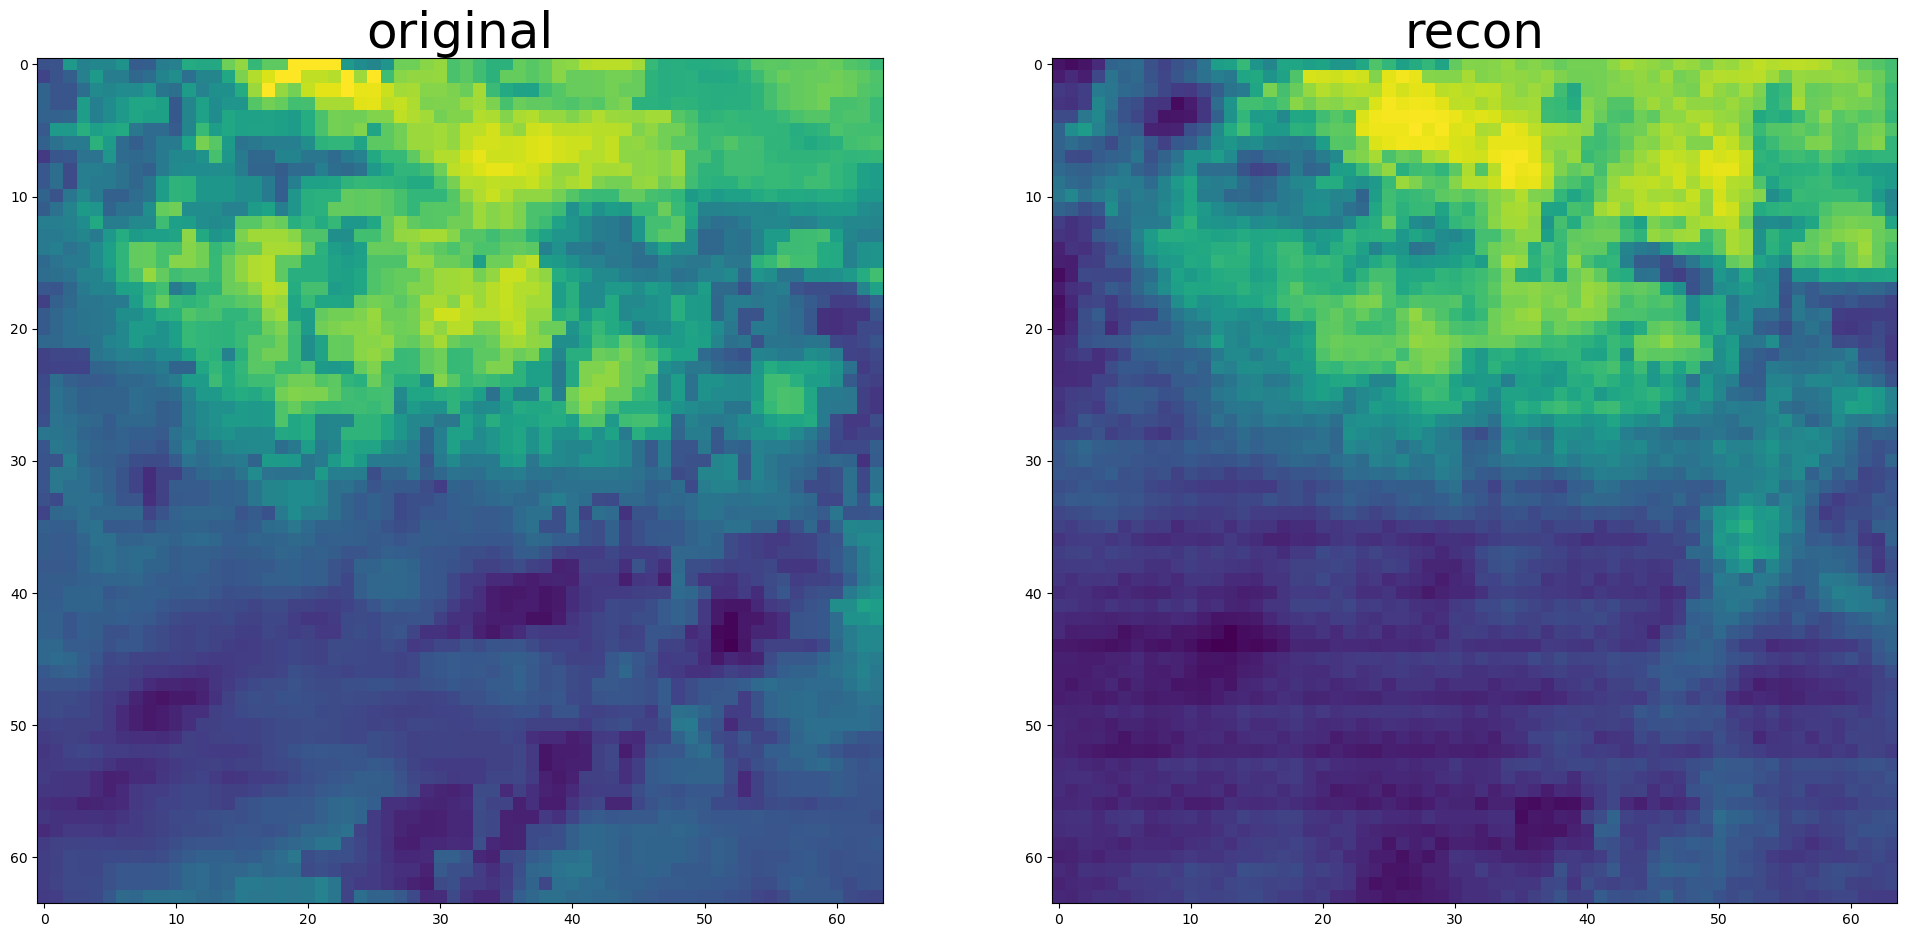

In [16]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(24, 12))
axs[0].imshow(batch[0, 0, :, :].cpu().detach().numpy())
axs[0].set_title('original', fontsize=36)
axs[1].imshow(recon[0, 0, :, :].cpu().detach().numpy())
axs[1].set_title('recon', fontsize=36)

In [17]:
z.shape

torch.Size([2, 1, 16, 16])

In [18]:
z

tensor([[[[-2.7854, -0.7054, -1.1076, -0.6811, -0.7856, -0.1592, -0.2513,
           -0.4614,  0.6807,  0.2356,  0.3549,  0.4328,  0.5481,  0.8290,
            0.8360,  0.1139],
          [-0.9703, -0.6190, -3.1999, -0.0915,  0.1737,  0.8426,  2.5443,
            1.9581,  1.4426,  0.0036, -0.2254,  0.1461,  1.1874, -0.5768,
            0.2795,  0.3288],
          [-0.1953, -0.8017, -0.6279, -0.4293, -2.1534, -0.4160,  0.5551,
            0.0654,  2.1005,  1.2848, -0.5148,  0.8829,  1.8718,  0.2898,
           -0.1236, -0.7565],
          [-1.2812, -0.8185, -0.0294, -0.6258, -0.4679, -1.0091, -0.0086,
           -1.1024,  1.0006, -0.7199,  0.6318,  0.3945,  2.3816, -0.8073,
           -0.2422,  0.5348],
          [-2.1172, -0.8887, -0.0042,  0.0788,  0.1693, -0.0977, -0.4570,
           -0.9938,  0.2769,  0.1193,  0.7485, -2.3846, -1.4323,  0.3783,
            0.0797, -0.0591],
          [-1.4688, -1.3636, -0.6276, -0.4815, -0.7722,  0.4558,  0.3960,
            0.4713,  0.2896,  0.6900